# Feature Scaling and Learning Rate

## Goals
- Run gradient descent on a larger multi-feature dataset
- Explore how the learning rate alpha affects whether gradient descent converges or diverges
- Fix slow/unstable training using feature scaling (z-score normalization)


In [11]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=2)
import copy

## Problem Statement

Same 4 features as before (size, bedrooms, floors, age), but a larger dataset this time - enough examples to clearly see how learning rate affects convergence.

In [2]:
np.random.seed(1)
m = 100
size = np.random.randint(800,2500,m)
bedrooms = np.random.randint(1,5,m)
floors = np.random.randint(1,3,m)
age = np.random.randint(1,80,m)

X_train = np.column_stack((size, bedrooms, floors, age))
y_train = (size * 0.2 + bedrooms * 15 - age * 1.5 + np.random.randn(m) * 20 + 50) 
X_features = ['size(sqft)', 'bedrooms', 'floors', 'age']


In [6]:
print(f"X_train shape: {X_train.shape}")
print(X_train[:5])
print(f"y_train shape: {y_train.shape}")
print(y_train[:5])

X_train shape: (100, 4)
[[1861    3    2   48]
 [1035    1    1   61]
 [1896    1    2   35]
 [1705    4    2   33]
 [1515    4    2   20]]
y_train shape: (100,)
[396.07 175.97 418.33 395.75 396.6 ]


Let's view the dataset by plotting each feature against price.

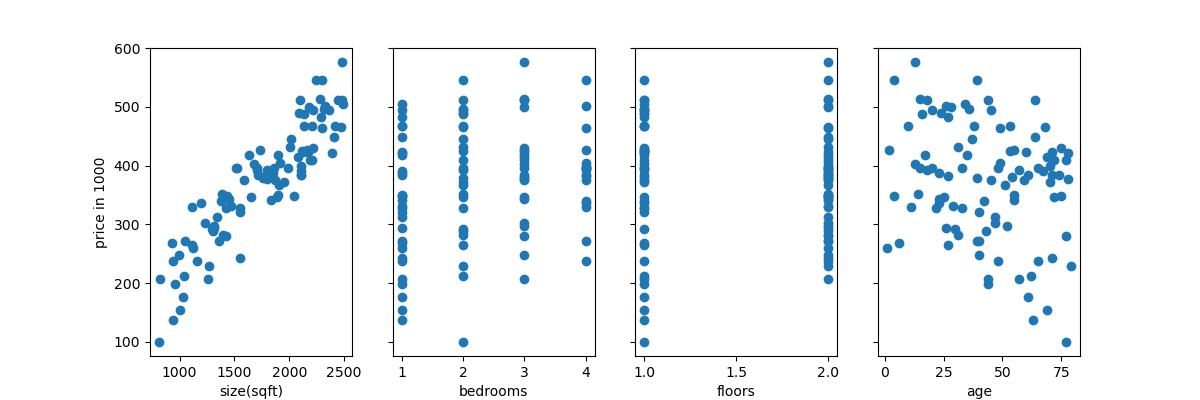

In [9]:
fig ,ax = plt.subplots(1,4, figsize=(12,4), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i],y_train)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("price in 1000")
plt.savefig("features_vs_price.png")
plt.close()

from IPython.display import Image
Image("features_vs_price.png")
    

## Gradient Descent With Multiple Variables

We'll reuse the compute_cost, compute_gradient, and gradient_descent functions built in the previous lab.

In [21]:
#cost_fucntion
def compute_cost(X, y, w, b):
    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        f_wb_i = np.dot(X[i], w) + b
        cost = cost + (f_wb_i - y[i])**2
    cost = cost / (2 * m)
    return cost
    
#compute_gradient
def compute_gradient(X, y, w, b):
    m, n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.
    for i in range(m):
        err = (np.dot(X[i], w) + b) - y[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err * X[i, j]
        dj_db = dj_db + err
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    return dj_db, dj_dw

#gradient_descent
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    J_history = []
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(num_iters):
        dj_db, dj_dw = gradient_function(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        if i < 100000:
            J_history.append(cost_function(X, y, w, b))
        if i % max(1, num_iters // 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}")
    return w, b, J_history

### alpha = 9.9e-7

Let's try a learning rate that's too large and see what happens.

In [22]:
initial_w = np.zeros(4)
initial_b = 0.
w_out, b_out, hist = gradient_descent(X_train, y_train, initial_w, initial_b,
                                        compute_cost, compute_gradient,
                                        alpha=9.9e-7, num_iters=10)


    

Iteration    0: Cost 368650.02
Iteration    1: Cost 1857569.67
Iteration    2: Cost 9374727.91
Iteration    3: Cost 47326849.13
Iteration    4: Cost 238936951.50
Iteration    5: Cost 1206325069.10
Iteration    6: Cost 6090408723.14
Iteration    7: Cost 30748839708.54
Iteration    8: Cost 155242657116.65
Iteration    9: Cost 783778616353.89


It appears the learning rate is too high. Cost is increasing rather than decreasing, meaning gradient descent is diverging instead of converging.

### alpha = 9e-7

Let's try a slightly smaller value and see what happens.

In [24]:
w_out, b_out, hist = gradient_descent(X_train, y_train, initial_w, initial_b,
                                        compute_cost, compute_gradient,
                                        alpha=9e-7, num_iters=10)

Iteration    0: Cost 278375.32
Iteration    1: Cost 1057906.35
Iteration    2: Cost 4027433.89
Iteration    3: Cost 15339480.95
Iteration    4: Cost 58431319.38
Iteration    5: Cost 222584323.71
Iteration    6: Cost 847904794.99
Iteration    7: Cost 3229985421.38
Iteration    8: Cost 12304225542.40
Iteration    9: Cost 46871415609.54


### alpha = 1e-7

Let's try an even smaller value.

In [25]:
w_out, b_out, hist = gradient_descent(X_train, y_train, initial_w, initial_b,
                                        compute_cost, compute_gradient,
                                        1e-7, 10)

Iteration    0: Cost 33796.64
Iteration    1: Cost 15757.09
Iteration    2: Cost  7610.06
Iteration    3: Cost  3930.69
Iteration    4: Cost  2268.99
Iteration    5: Cost  1518.51
Iteration    6: Cost  1179.56
Iteration    7: Cost  1026.46
Iteration    8: Cost   957.30
Iteration    9: Cost   926.05


## Feature Scaling

The problem: alpha has to be shared across all weights, but features vary wildly in scale (size ~2000, floors ~1-2). This forces alpha to be extremely small just to avoid diverging, which makes training painfully slow.

The fix: rescale all features to a similar range before training, so one shared alpha works well for all of them.

In [31]:
def z_score_normalize_features(x):
    mu = np.mean(x,axis=0)
    sigma = np.std(x,axis=0)
    X_norm = (x-mu)/sigma
    return X_norm,mu,sigma

Let's normalize the data and compare it to the original.

In [32]:
X_norm, X_mu, X_sigma = z_score_normalize_features(X_train)
print(f"X_mu = {X_mu}")
print(f"X_sigma = {X_sigma}")
print(f"Peak to Peak range by column in Raw X: {np.ptp(X_train, axis=0)}")
print(f"Peak to Peak range by column in Normalized X: {np.ptp(X_norm, axis=0)}")

X_mu = [1.75e+03 2.29e+00 1.54e+00 4.34e+01]
X_sigma = [464.85   1.09   0.5   21.56]
Peak to Peak range by column in Raw X: [1674    3    1   78]
Peak to Peak range by column in Normalized X: [3.6  2.75 2.01 3.62]


In [33]:
w_norm, b_norm, hist_norm = gradient_descent(X_norm, y_train, np.zeros(4), 0.,
                                               compute_cost, compute_gradient,
                                               0.1, 1000)

Iteration    0: Cost 59793.77
Iteration  100: Cost   202.32
Iteration  200: Cost   202.32
Iteration  300: Cost   202.32
Iteration  400: Cost   202.32
Iteration  500: Cost   202.32
Iteration  600: Cost   202.32
Iteration  700: Cost   202.32
Iteration  800: Cost   202.32
Iteration  900: Cost   202.32


In [34]:
m = X_norm.shape[0]
yp = np.zeros(m)
for i in range(m):
    yp[i] = np.dot(X_norm[i], w_norm) + b_norm
print(yp[:5])
print(y_train[:5])

[393.71 191.59 391.12 398.83 380.37]
[396.07 175.97 418.33 395.75 396.6 ]


In [35]:
x_house = np.array([1200, 3, 1, 40])
x_house_norm = (x_house - X_mu) / X_sigma
x_house_predict = np.dot(x_house_norm, w_norm) + b_norm
print(f"predicted price: ${x_house_predict*1000:0.0f}")

predicted price: $282205


## Summary
Learned that gradient descent needs a very small learning rate when features have wildly different scales (like sqft vs floor count). Z-score normalization rescales all features to comparable ranges, allowing a much larger learning rate and dramatically faster convergence.